# Innovation Results: Three-Class Classification, Ensemble & Calibration

This notebook presents the results of the innovations added on top of the binary classification baseline:

1. **Three-class classification**: distinguishing NORMAL, BACTERIAL PNEUMONIA, and VIRAL PNEUMONIA
2. **Ensemble**: averaging probabilities from all ResNet18 + DenseNet121 checkpoints
3. **Calibration analysis**: ECE, reliability diagrams, and optimal decision thresholds
4. **Grad-CAM visualisations**: explainability for three-class predictions

All models were trained with seeds 0, 1, 2 for reproducibility. Results shown are mean ± std across seeds.

In [13]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import numpy as np
import pandas as pd

METRICS_DIR = Path("../results/metrics")
FIGURES_DIR = Path("../results/figures")
GRADCAM_DIR = Path("../results/gradcam")

MODELS = ["resnet18", "densenet121"]
SEEDS = [0, 1, 2]
CLASS_NAMES = ["NORMAL", "BACTERIA", "VIRUS"]
THREE_CLASS_METRICS = ["accuracy", "precision_macro", "recall_macro", "f1_macro", "auroc"]

def load_json(path):
    with open(path) as f:
        return json.load(f)

---
## 1. Three-Class Classification Results

ResNet18 and DenseNet121 were fine-tuned for 3-class classification using a two-phase strategy:
- **Phase 1 (head-only):** only the classification head is trained, backbone frozen
- **Phase 2 (fine-tune):** full model unfrozen with a lower learning rate

Labels are derived automatically from the Kermany dataset filenames (`_bacteria_` / `_virus_`), so no extra annotation was required.

In [14]:
rows = []
for model in MODELS:
    for seed in SEEDS:
        path = METRICS_DIR / f"{model}_3class_seed{seed}.json"
        if not path.exists():
            continue
        data = load_json(path)
        row = {"Model": model, "Seed": seed}
        for m in THREE_CLASS_METRICS:
            row[m] = data.get(m)
        for cls in CLASS_NAMES:
            row[f"F1_{cls}"] = data.get("f1_per_class", {}).get(cls)
        rows.append(row)

# Ensemble
ens_path = METRICS_DIR / "ensemble_resnet18_densenet121_3class.json"
if ens_path.exists():
    data = load_json(ens_path)
    row = {"Model": "ensemble", "Seed": "—"}
    for m in THREE_CLASS_METRICS:
        row[m] = data.get(m)
    for cls in CLASS_NAMES:
        row[f"F1_{cls}"] = data.get("f1_per_class", {}).get(cls)
    rows.append(row)

df = pd.DataFrame(rows)
df

,Model,Seed,accuracy,precision_macro,recall_macro,f1_macro,auroc,F1_NORMAL,F1_BACTERIA,F1_VIRUS
0,resnet18,0,0.769231,0.789325,0.767199,0.752704,0.939559,0.726287,0.859259,0.672566
1,resnet18,1,0.764423,0.811733,0.781250,0.756084,0.914286,0.714286,0.900212,0.653753
2,resnet18,2,0.774038,0.797405,0.779703,0.756553,0.945048,0.696133,0.899614,0.673913
3,densenet121,0,0.818910,0.823722,0.820747,0.807293,0.951704,0.804020,0.907631,0.710227
4,densenet121,1,0.839744,0.845754,0.845652,0.829539,0.963161,0.810127,0.918489,0.760000
5,densenet121,2,0.782051,0.800611,0.785217,0.767372,0.952584,0.724324,0.870544,0.707246
6,ensemble,—,0.817308,0.825864,0.819726,0.803495,0.961292,0.774026,0.914397,0.722063


In [15]:
# Summary: mean ± std per model
seed_df = df[df["Seed"] != "—"].copy()
seed_df[THREE_CLASS_METRICS] = seed_df[THREE_CLASS_METRICS].astype(float)

summary_rows = []
for model in MODELS:
    sub = seed_df[seed_df["Model"] == model]
    row = {"Model": model}
    for m in THREE_CLASS_METRICS:
        mean = sub[m].mean()
        std = sub[m].std()
        row[m] = f"{mean:.4f} ± {std:.4f}"
    for cls in CLASS_NAMES:
        col = f"F1_{cls}"
        mean = sub[col].astype(float).mean()
        std = sub[col].astype(float).std()
        row[col] = f"{mean:.4f} ± {std:.4f}"
    summary_rows.append(row)

# Ensemble row (no std)
ens_row_df = df[df["Model"] == "ensemble"]
if not ens_row_df.empty:
    row = {"Model": "ensemble"}
    for m in THREE_CLASS_METRICS:
        row[m] = f"{float(ens_row_df[m].iloc[0]):.4f}"
    for cls in CLASS_NAMES:
        col = f"F1_{cls}"
        row[col] = f"{float(ens_row_df[col].iloc[0]):.4f}"
    summary_rows.append(row)

summary_df = pd.DataFrame(summary_rows).set_index("Model")
print("Three-Class Results Summary")
summary_df

Three-Class Results Summary


,accuracy,precision_macro,recall_macro,f1_macro,auroc,F1_NORMAL,F1_BACTERIA,F1_VIRUS
Model,,,,,,,,
resnet18,0.7692 ± 0.0048,0.7995 ± 0.0113,0.7761 ± 0.0077,0.7551 ± 0.0021,0.9330 ± 0.0164,0.7122 ± 0.0152,0.8864 ± 0.0235,0.6667 ± 0.0113
densenet121,0.8136 ± 0.0292,0.8234 ± 0.0226,0.8172 ± 0.0304,0.8014 ± 0.0315,0.9558 ± 0.0064,0.7795 ± 0.0479,0.8989 ± 0.0251,0.7258 ± 0.0296
ensemble,0.8173,0.8259,0.8197,0.8035,0.9613,0.7740,0.9144,0.7221


### 1.1 Confusion Matrices

Confusion matrices for each model/seed and the ensemble. Rows = actual class, columns = predicted class.

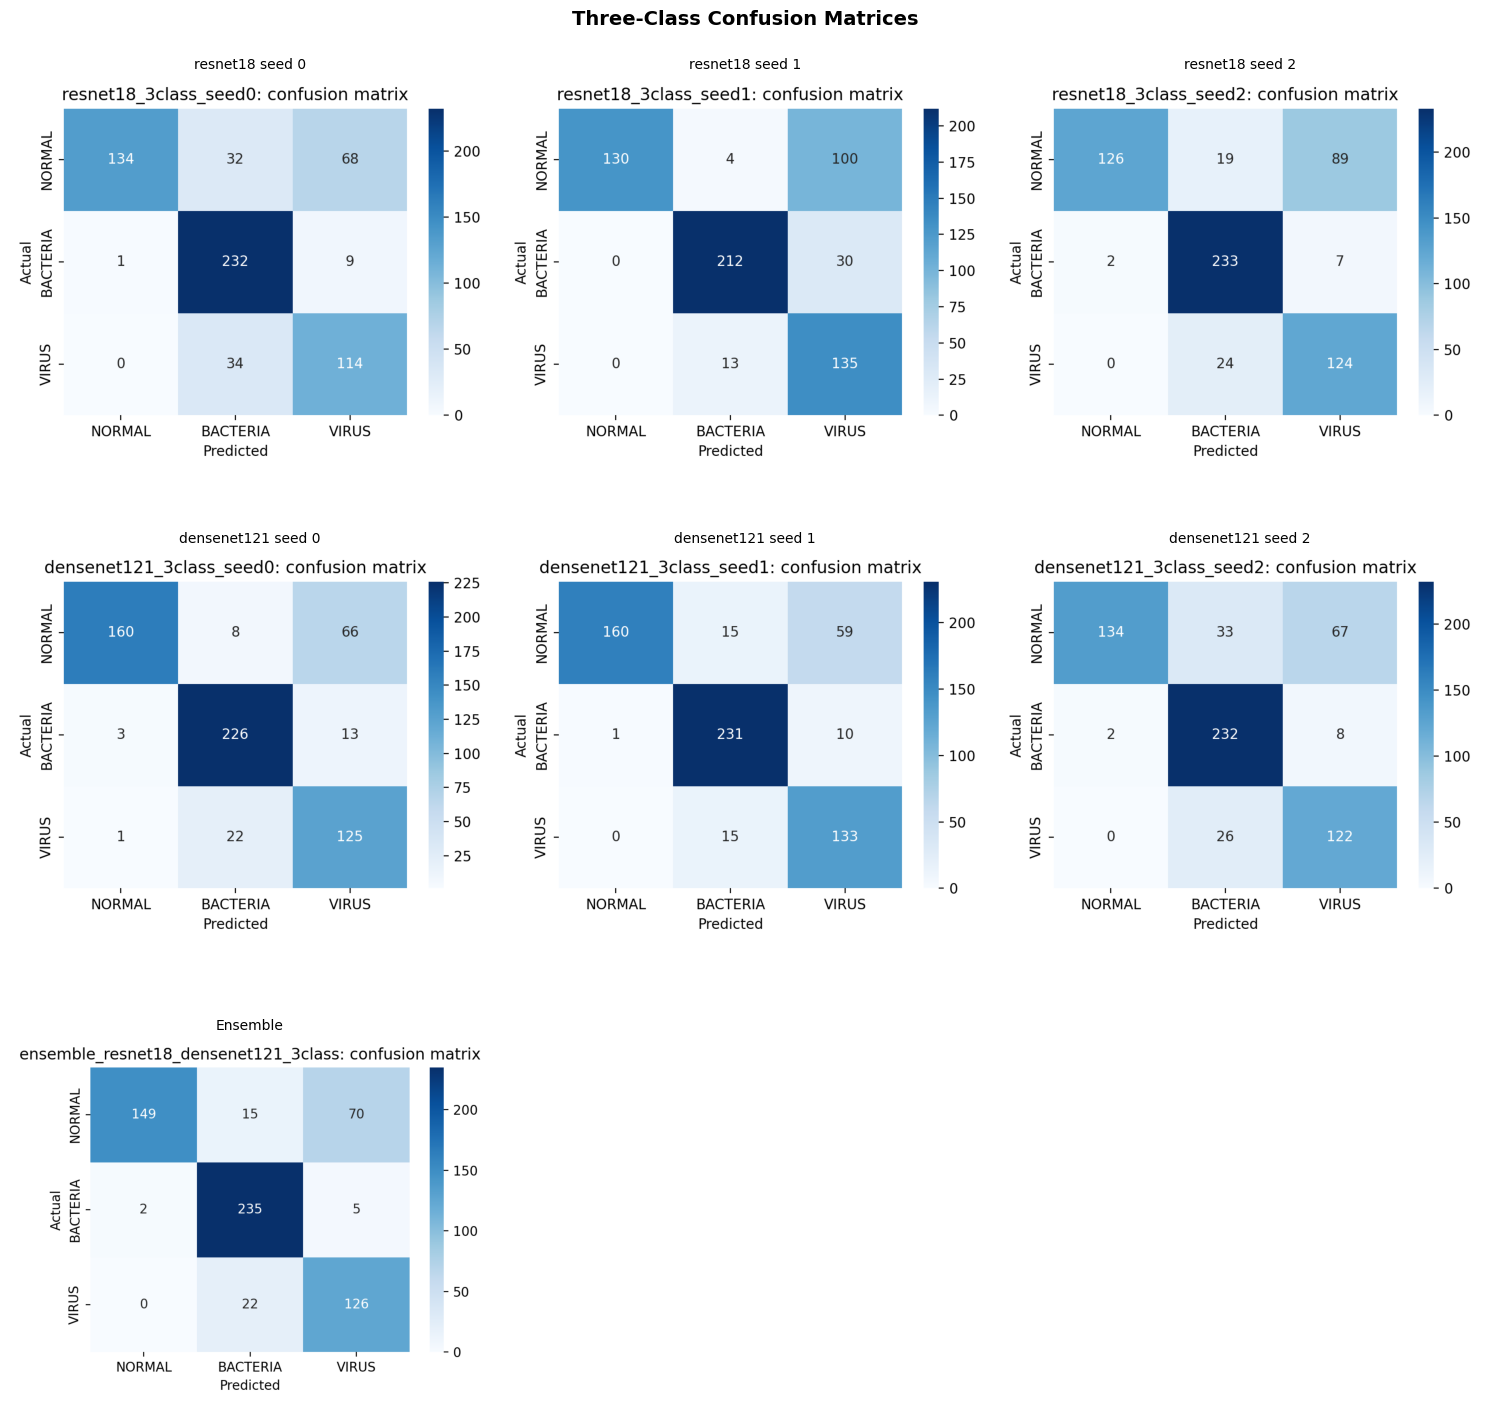

In [16]:
images_to_show = []
for model in MODELS:
    for seed in SEEDS:
        images_to_show.append((f"{model} seed {seed}", FIGURES_DIR / f"{model}_3class_seed{seed}_confusion_matrix.png"))
images_to_show.append(("Ensemble", FIGURES_DIR / "ensemble_resnet18_densenet121_3class_confusion_matrix.png"))

n = len(images_to_show)
cols = 3
rows = (n + cols - 1) // cols
fig, axes = plt.subplots(rows, cols, figsize=(15, 5 * rows))
all_axes = np.array(axes).flatten()

for i, (title, path) in enumerate(images_to_show):
    ax = all_axes[i]
    if path.exists():
        ax.imshow(mpimg.imread(path))
        ax.set_title(title, fontsize=10)
    else:
        ax.text(0.5, 0.5, "Not found", ha="center", va="center")
    ax.axis("off")

for ax in all_axes[n:]:
    ax.set_visible(False)

plt.suptitle("Three-Class Confusion Matrices", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

### 1.2 Training Curves

Two-phase training: head-only followed by full fine-tune. The y-axis shows F1 macro (used instead of accuracy for multi-class balance).

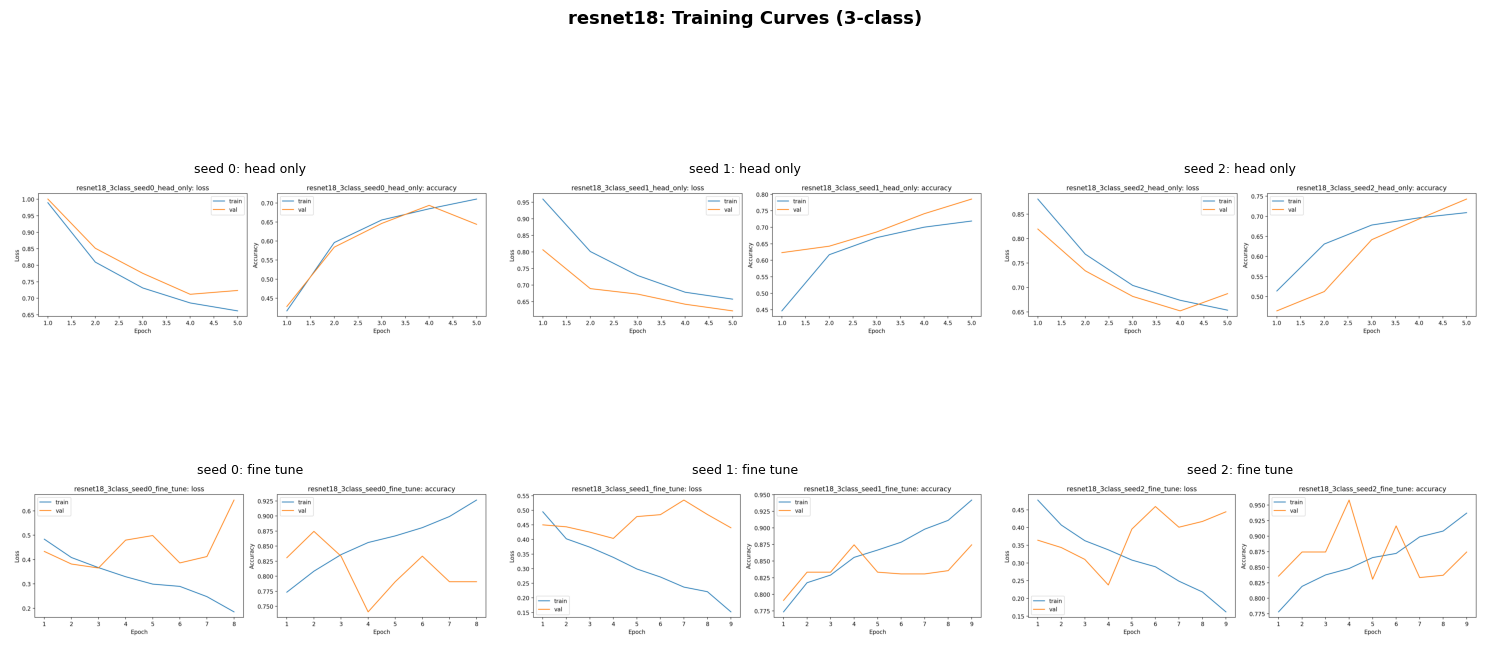

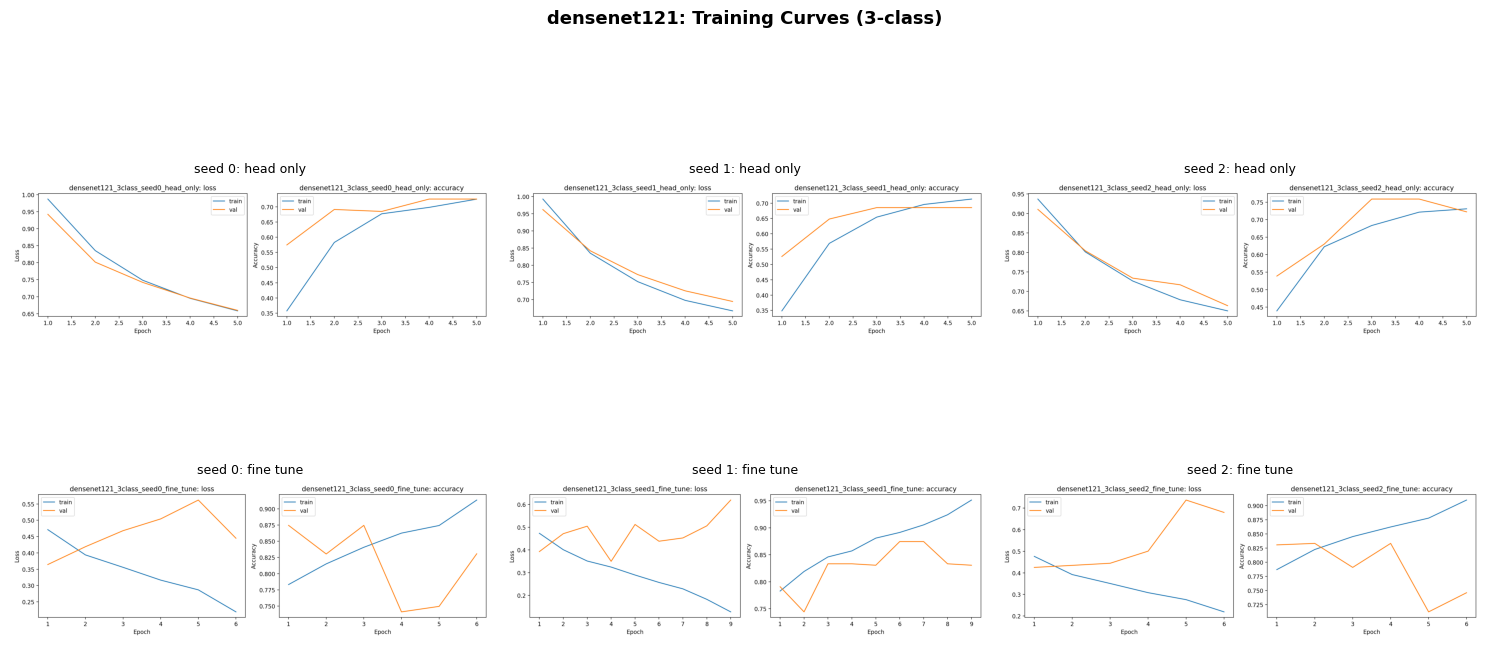

In [17]:
for model in MODELS:
    fig, axes = plt.subplots(2, 3, figsize=(15, 8))
    fig.suptitle(f"{model}: Training Curves (3-class)", fontsize=13, fontweight="bold")
    for col, seed in enumerate(SEEDS):
        for row, phase in enumerate(["head_only", "fine_tune"]):
            path = FIGURES_DIR / f"{model}_3class_seed{seed}_{phase}_training_curves.png"
            ax = axes[row][col]
            if path.exists():
                ax.imshow(mpimg.imread(path))
                ax.set_title(f"seed {seed}: {phase.replace('_', ' ')}", fontsize=9)
            else:
                ax.text(0.5, 0.5, "Not found", ha="center", va="center")
            ax.axis("off")
    plt.tight_layout()
    plt.show()

### 1.3 Metric Comparison

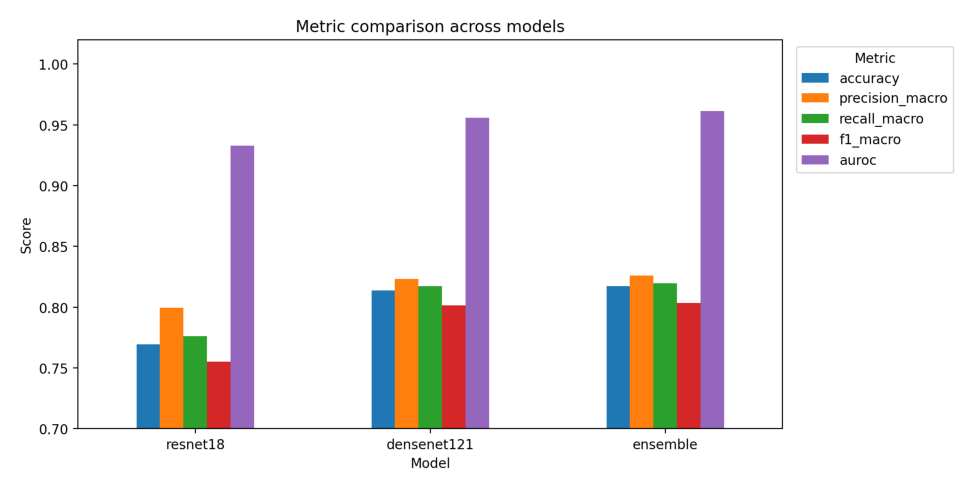

In [18]:
path = FIGURES_DIR / "metric_comparison_3class.png"
if path.exists():
    fig, ax = plt.subplots(figsize=(12, 5))
    ax.imshow(mpimg.imread(path))
    ax.axis("off")
    plt.tight_layout()
    plt.show()

---
## 2. Ensemble

The ensemble averages the softmax probabilities of all 6 checkpoints (ResNet18 × 3 seeds + DenseNet121 × 3 seeds). This reduces variance across seeds and typically improves robustness.

Both binary and three-class ensembles were computed.

In [19]:
# Binary ensemble
ens_bin = load_json(METRICS_DIR / "ensemble_resnet18_densenet121.json")
# Three-class ensemble
ens_3cls = load_json(METRICS_DIR / "ensemble_resnet18_densenet121_3class.json")

print("Binary Ensemble")
print(f"  Accuracy   : {ens_bin['accuracy']:.4f}")
print(f"  F1         : {ens_bin['f1']:.4f}")
print(f"  AUROC      : {ens_bin['auroc']:.4f}")
print(f"  Recall     : {ens_bin['recall']:.4f}")
print(f"  Specificity: {ens_bin['specificity']:.4f}")

print("\nThree-Class Ensemble")
print(f"  Accuracy   : {ens_3cls['accuracy']:.4f}")
print(f"  F1 macro   : {ens_3cls['f1_macro']:.4f}")
print(f"  AUROC      : {ens_3cls['auroc']:.4f}")
print(f"  Members    : {ens_3cls['num_members']} checkpoints")
print()
print("Per-class F1 (3-class ensemble):")
for cls, val in ens_3cls["f1_per_class"].items():
    print(f"  {cls:<11}: {val:.4f}")

Binary Ensemble
  Accuracy   : 0.8558
  F1         : 0.8963
  AUROC      : 0.9630
  Recall     : 0.9974
  Specificity: 0.6197

Three-Class Ensemble
  Accuracy   : 0.8173
  F1 macro   : 0.8035
  AUROC      : 0.9613
  Members    : 6 checkpoints

Per-class F1 (3-class ensemble):
  NORMAL     : 0.7740
  BACTERIA   : 0.9144
  VIRUS      : 0.7221


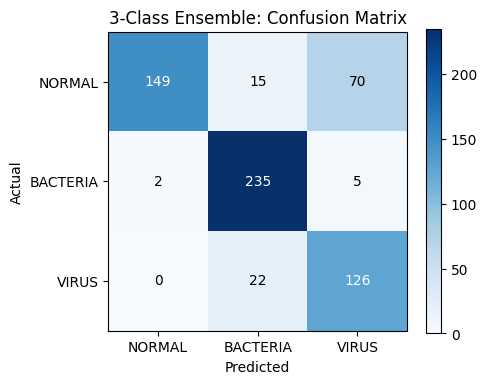

In [20]:
# Ensemble confusion matrix (inline, from JSON)
cm = np.array(ens_3cls["confusion_matrix"])
fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(cm, cmap="Blues")
ax.set_xticks(range(3))
ax.set_yticks(range(3))
ax.set_xticklabels(CLASS_NAMES)
ax.set_yticklabels(CLASS_NAMES)
ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")
ax.set_title("3-Class Ensemble: Confusion Matrix")
for i in range(3):
    for j in range(3):
        ax.text(j, i, str(cm[i, j]), ha="center", va="center",
                color="white" if cm[i, j] > cm.max() / 2 else "black")
plt.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()

---
## 3. Calibration Analysis

A well-calibrated model outputs probabilities that reflect true likelihoods. If it predicts 80% confidence, it should be correct ~80% of the time.

**Expected Calibration Error (ECE)** measures the average gap between confidence and accuracy across bins. Lower is better.

Two clinical threshold scenarios are computed for binary models:
- **Screening threshold**: highest threshold achieving ≥99% recall (minimise false negatives)
- **F1 threshold**: threshold maximising F1 (balanced precision/recall)

In [21]:
cal = load_json(METRICS_DIR / "calibration_results.json")

cal_rows = []
for r in cal:
    ece = f"{r['ece_mean']:.4f}"
    if r.get("ece_std") is not None:
        ece += f" ± {r['ece_std']:.4f}"
    thr_screen = f"{r['threshold_screening_mean']:.4f}" if r.get("threshold_screening_mean") is not None else "n/a (multiclass)"
    thr_f1 = f"{r['threshold_f1_mean']:.4f}" if r.get("threshold_f1_mean") is not None else "n/a (multiclass)"
    cal_rows.append({"Model": r["model"], "ECE": ece, "Threshold (screening)": thr_screen, "Threshold (F1)": thr_f1})

pd.DataFrame(cal_rows).set_index("Model")

,ECE,Threshold (screening),Threshold (F1)
Model,,,
custom_cnn,0.1076 ± 0.0509,0.2450,0.5960
resnet18,0.1602 ± 0.0157,0.5926,0.9812
densenet121,0.1532 ± 0.0153,0.8595,0.9949
ensemble_resnet18_densenet121,0.1564,0.7506,0.9860
resnet18_3class,0.2657 ± 0.0861,n/a (multiclass),n/a (multiclass)
densenet121_3class,0.2454 ± 0.0267,n/a (multiclass),n/a (multiclass)
ensemble_resnet18_densenet121_3class,0.2765,n/a (multiclass),n/a (multiclass)


### 3.1 Reliability Diagrams

Each bar shows the fraction of correct predictions for samples in that confidence bin. A perfectly calibrated model follows the diagonal. The red line shows the actual model confidence vs accuracy.

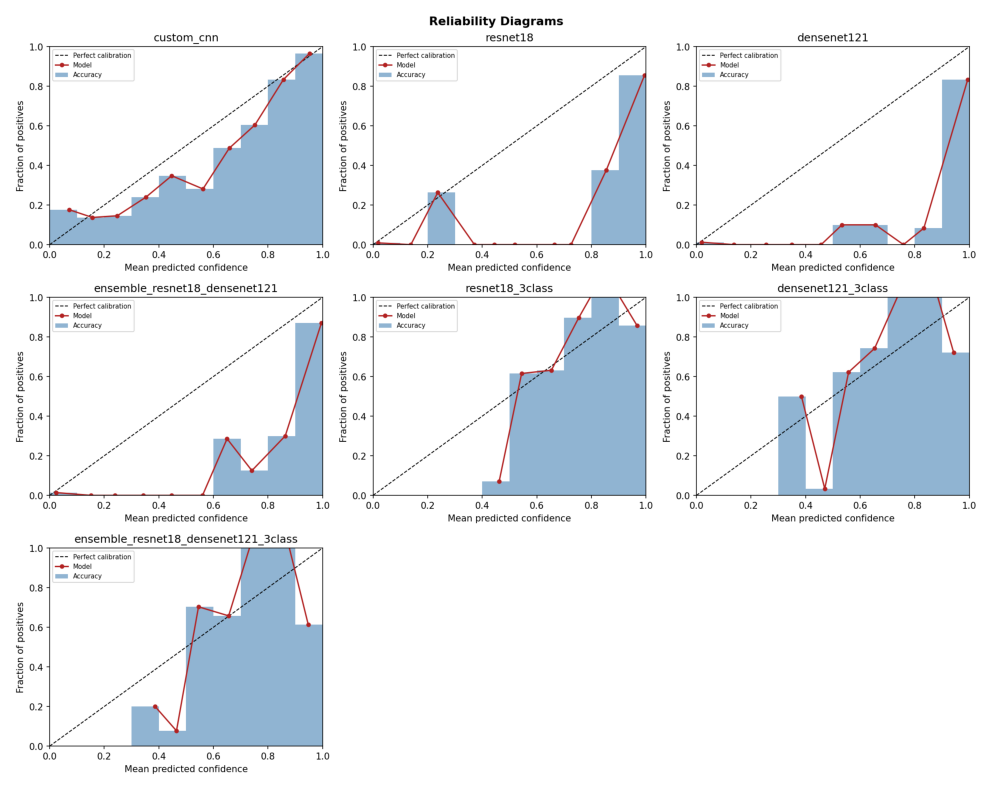

In [22]:
path = FIGURES_DIR / "reliability_diagrams.png"
if path.exists():
    fig, ax = plt.subplots(figsize=(16, 8))
    ax.imshow(mpimg.imread(path))
    ax.axis("off")
    plt.tight_layout()
    plt.show()

**Reading the diagrams:**
- Binary models (custom_cnn, resnet18, densenet121, ensemble) tend to be overconfident: most predictions cluster near 0 or 1, few intermediate confidence scores.
- Three-class models show higher ECE partly because calibration was computed using the max class probability, which is a coarser proxy for a multiclass setting.
- The custom_cnn has the lowest ECE but this reflects that its probabilities spread more evenly, not that it is more accurate.

---
## 4. Grad-CAM Visualisations (Three-Class)

Grad-CAM highlights the image regions that most influenced the model's decision. These were generated for DenseNet121 (best-performing individual model, seed 1).

- **correct_X**: the model correctly classified class X, heat concentrated in diagnostically relevant regions
- **wrong_X_as_Y**: the model misclassified class X as Y, useful to understand failure modes

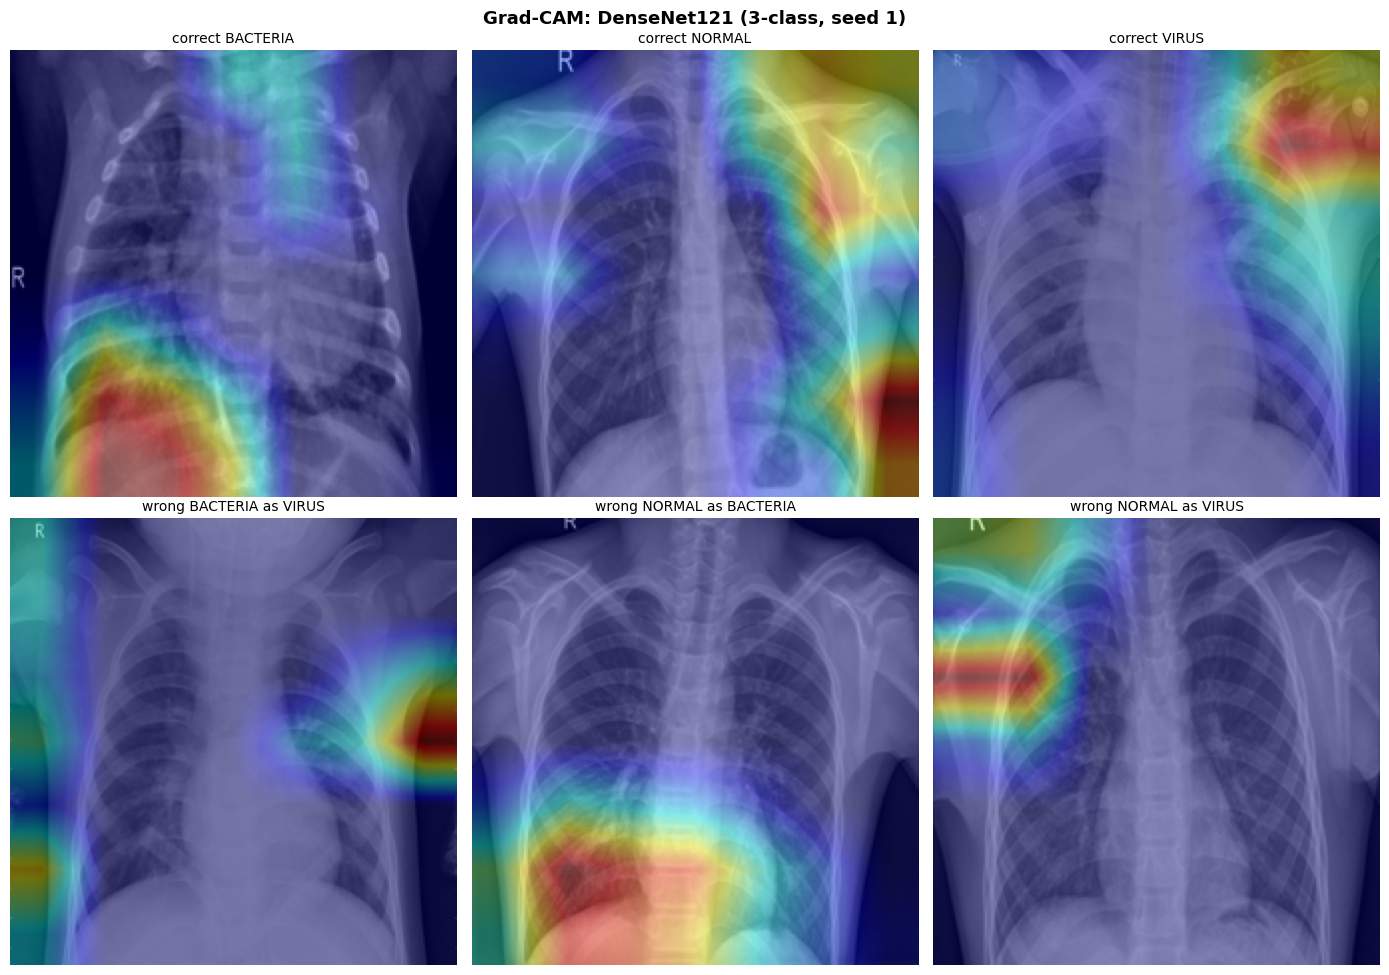

In [23]:
gradcam_files = sorted(GRADCAM_DIR.glob("densenet121_3class_*.png"))

n = len(gradcam_files)
cols = 3
rows = (n + cols - 1) // cols
fig, axes = plt.subplots(rows, cols, figsize=(14, 5 * rows))
all_axes = np.array(axes).flatten()

for i, path in enumerate(gradcam_files):
    ax = all_axes[i]
    ax.imshow(mpimg.imread(path))
    # Strip model prefix and image ID suffix to get the meaningful label
    # e.g. densenet121_3class_wrong_BACTERIA_as_VIRUS_person102_bacteria_4 -> wrong BACTERIA as VIRUS
    stem = path.stem.replace("densenet121_3class_", "")  # wrong_BACTERIA_as_VIRUS_person102_bacteria_4
    # Drop the trailing image filename (starts when we hit a part with digits or "IM")
    parts = stem.split("_")
    label_parts = []
    for p in parts:
        if p[0].isdigit() or p.startswith("IM") or p.startswith("person"):
            break
        label_parts.append(p)
    label = " ".join(label_parts)
    ax.set_title(label, fontsize=10)
    ax.axis("off")

for ax in all_axes[n:]:
    ax.set_visible(False)

plt.suptitle("Grad-CAM: DenseNet121 (3-class, seed 1)", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

**Observations:**
- **correct BACTERIA:** heat concentrates in the lower-left lung lobe, consistent with the focal consolidation pattern typical of bacterial pneumonia. This is the most clinically plausible activation.
- **correct NORMAL:** activation is diffuse across the upper chest and mediastinum, with no focal hot spot. The model correctly finds nothing specific to flag.
- **correct VIRUS:** activation appears in the upper-right region, outside the lung parenchyma. Viral pneumonia has a diffuse bilateral interstitial pattern that is hard to localise, so the model struggles to anchor on a specific region even when it predicts correctly.
- **wrong BACTERIA as VIRUS:** heat is dispersed laterally on both sides rather than concentrated in one lobe. The model interpreted the bilateral spread as a viral pattern, which is a clinically plausible confusion since some bacterial cases present with a mixed or diffuse appearance.
- **wrong NORMAL as BACTERIA:** the model focuses on the lower-left lobe and diaphragm, mistaking the cardiac shadow or a vascular structure for a consolidation.
- **wrong NORMAL as VIRUS:** activation in the lower-central and left region. The model picks up on normal vascular markings and interprets them as an interstitial infiltrate.


---
## 5. Key Takeaways

| Finding | Detail |
|---|---|
| Best 3-class model | DenseNet121 seed 1: F1 macro 0.8295, AUROC 0.9632 |
| Ensemble benefit | Marginal (+0.03 AUROC vs best individual for 3-class): mainly reduces variance |
| Hardest class | VIRUS: F1 0.65–0.76 vs 0.87–0.92 for BACTERIA |
| Calibration | All models overconfident; binary ECE ~0.15, 3-class ECE ~0.25 |
| Screening threshold | Lowering threshold to ~0.75 (ensemble) achieves ≥99% recall for binary task |
| Grad-CAM | BACTERIA activations are clinically plausible; VIRUS activations less focal |

The main limitation is the difficulty of distinguishing viral pneumonia, which is a known challenge even for experienced radiologists. Future work could explore data augmentation weighted towards VIRUS examples or semi-supervised learning to leverage unlabelled data.